# Árvore de Decisão para Classificação com Desequilíbrio de Classes — Machine Learning I (CC2008)

**Algoritmo escolhido:** Árvore de Decisão com critério de Gini (implementação CART)  
**Característica abordada:** Dataset Group 5 — Desequilíbrio de Classes (Class Imbalance)  

A Árvore de Decisão é um algoritmo de classificação que constrói recursivamente divisões binárias dos dados, maximizando um critério de pureza em cada nó. Neste trabalho, estudamos o comportamento do algoritmo standard em contextos com desequilíbrio de classes, avaliamos empiricamente as suas limitações e motivamos a modificação proposta na Fase 2.

## Setup Inicial

Importação das dependências. Apenas são usadas bibliotecas de suporte (NumPy, pandas, matplotlib, sklearn para utilidades de avaliação) — a implementação do algoritmo é feita de raiz.

In [21]:
import numpy as np
import pandas as pd
import random
import warnings
from functools import partial
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# ── Configuração global ───────────────────────────────────────────────────────
RANDOM_STATE = 42
N_FOLDS      = 5
MAX_DEPTH    = 5
MIN_SAMPLES  = 5
MAX_SAMPLES  = 500   
DATA_DIR     = Path('data/class_imbalance/class_imbalance')

## Critério de Impureza de Gini

A Árvore de Decisão decide como dividir os dados em cada nó com base num critério de **pureza**. O critério standard para classificação é o **índice de Gini**:

$$\text{Gini}(S) = 1 - \sum_{c=1}^{k} p_c^2$$

onde $p_c$ é a proporção da classe $c$ no conjunto $S$, e $k$ é o número de classes. Um nó é perfeitamente puro ($\text{Gini}=0$) quando todas as instâncias pertencem à mesma classe; é maximamente impuro ($\text{Gini}=0.5$ para $k=2$) quando as classes estão em proporções iguais.

O **ganho de Gini** para uma divisão $S \to S_L \cup S_R$ é:

$$\Delta\text{Gini}(S, S_L, S_R) = \text{Gini}(S) - \frac{|S_L|}{|S|}\,\text{Gini}(S_L) - \frac{|S_R|}{|S|}\,\text{Gini}(S_R)$$

O algoritmo procura, em cada nó, a feature $j$ e o limiar $\theta$ que **maximizam** este ganho — estratégia *greedy* que é a base do algoritmo **CART** (*Classification and Regression Trees*).

As funções auxiliares de divisão dos dados são apresentadas abaixo.

In [22]:
def split(X_col, y, value):
    """Separa os rótulos y pelo limiar value aplicado à coluna X_col."""
    y = np.asarray(y).ravel()
    left_mask = X_col < value
    return y[left_mask], y[~left_mask]


def split_dataset(X, target, feature_idx, threshold, return_X=True):
    """Divide X e o dicionário target pelo limiar na feature feature_idx."""
    left_mask  = X[:, feature_idx] < threshold
    right_mask = ~left_mask
    left_target  = {k: v[left_mask]  for k, v in target.items()}
    right_target = {k: v[right_mask] for k, v in target.items()}
    if return_X:
        return X[left_mask], X[right_mask], left_target, right_target
    return left_target, right_target


print("Funções auxiliares de divisão definidas.")

Funções auxiliares de divisão definidas.


## Implementação da Árvore de Decisão (de raiz)

A Árvore de Decisão é implementada de raiz como uma estrutura recursiva binária. Cada nó interno armazena:
- `column_index`: índice da feature usada na divisão
- `threshold`: limiar de decisão ($x_j < \theta$ → ramo esquerdo)
- `impurity`: ganho de Gini desta divisão
- `left_child`, `right_child`: sub-árvores recursivas

Cada folha armazena `outcome`: um vector de probabilidades por classe $\hat{p}(y = c \mid x \in \text{folha})$, calculado pela proporção de cada classe nas instâncias de treino que chegam à folha. A previsão devolve a **probabilidade da classe positiva** (classe 1), permitindo o cálculo de AUC-ROC com limiares variáveis.

O treino segue o algoritmo CART:
1. Para cada feature amostrada, calcular os limiares candidatos como médias entre valores únicos consecutivos
2. Escolher a divisão com maior ganho de Gini
3. Recursão, parando quando `max_depth = 0`, `n_samples ≤ min_samples_split`, ou `gain ≤ minimum_gain`

O critério de impureza é passado como **função parametrizável**, o que permite trocar o Gini standard pelo Gini ponderado sem alterar a estrutura da árvore.

In [23]:
class Tree(object):
    """Implementação recursiva de uma árvore de decisão binária."""

    def __init__(self, regression=False, criterion=None, n_classes=None):
        self.regression    = regression
        self.criterion     = criterion
        self.n_classes     = n_classes
        self.impurity      = None
        self.threshold     = None
        self.column_index  = None
        self.outcome       = None
        self.loss          = None
        self.left_child    = None
        self.right_child   = None

    @property
    def is_terminal(self):
        return not bool(self.left_child and self.right_child)

    def _find_splits(self, X):
        """Candidatos a limiar: médias entre valores únicos consecutivos."""
        x_unique = np.unique(X)
        return [(x_unique[i - 1] + x_unique[i]) / 2.0 for i in range(1, len(x_unique))]

    def _find_best_split(self, X, target, n_features):
        """Pesquisa greedy da melhor divisão num subconjunto aleatório de features."""
        subset = random.sample(range(X.shape[1]), n_features)
        max_gain, max_col, max_val = None, None, None

        for column in subset:
            for value in self._find_splits(X[:, column]):
                splits = split(X[:, column], target["y"], value)
                gain   = self.criterion(target["y"], splits)
                if max_gain is None or gain > max_gain:
                    max_col, max_val, max_gain = column, value, gain
        return max_col, max_val, max_gain

    def _train(self, X, target, max_features=None, min_samples_split=10,
               max_depth=None, minimum_gain=0.0):
        try:
            assert X.shape[0] > min_samples_split
            assert max_depth > 0
            if max_features is None:
                max_features = X.shape[1]

            column, value, gain = self._find_best_split(X, target, max_features)
            assert gain is not None and gain > minimum_gain

            self.column_index = column
            self.threshold    = value
            self.impurity     = gain

            left_X, right_X, left_target, right_target = split_dataset(
                X, target, column, value
            )

            self.left_child = Tree(self.regression, self.criterion, self.n_classes)
            self.left_child._train(left_X, left_target, max_features,
                                   min_samples_split, max_depth - 1, minimum_gain)

            self.right_child = Tree(self.regression, self.criterion, self.n_classes)
            self.right_child._train(right_X, right_target, max_features,
                                    min_samples_split, max_depth - 1, minimum_gain)
        except AssertionError:
            self._calculate_leaf_value(target)

    def train(self, X, target, max_features=None, min_samples_split=10,
              max_depth=None, minimum_gain=0.0):
        """Treina a árvore a partir de X (features) e target (rótulos)."""
        if not isinstance(target, dict):
            target = {"y": np.asarray(target, dtype=int)}
        if not self.regression:
            self.n_classes = len(np.unique(target["y"]))
        self._train(X, target, max_features=max_features,
                    min_samples_split=min_samples_split,
                    max_depth=max_depth, minimum_gain=minimum_gain)

    def _calculate_leaf_value(self, targets):
        """Calcula o valor da folha: probabilidade por classe (classificação)."""
        y = targets["y"].astype(int)
        if self.n_classes is None:
            self.n_classes = int(y.max()) + 1
        self.outcome = np.bincount(y, minlength=self.n_classes) / len(y)

    def predict_row(self, row):
        """Previsão para uma única instância: probabilidade da classe 1."""
        if not self.is_terminal:
            child = self.left_child if row[self.column_index] < self.threshold \
                    else self.right_child
            return child.predict_row(row)
        if isinstance(self.outcome, np.ndarray):
            return self.outcome[1]   # P(y=1)
        return float(self.outcome)

    def predict(self, X):
        """Devolve P(y=1) para cada linha de X."""
        return np.array([self.predict_row(X[i]) for i in range(X.shape[0])])


print("Classe Tree definida (CART, critério parametrizável).")

Classe Tree definida (CART, critério parametrizável).


## Árvore de Decisão e Desequilíbrio de Classes — Análise Teórica

### O Problema do Desequilíbrio de Classes

Em datasets com desequilíbrio de classes (*class imbalance*), a proporção de instâncias da classe minoritária é muito pequena — neste grupo de datasets, o *Imbalance Ratio* (IR = $n_{\text{min}} / n_{\text{max}}$) varia entre 0.007 e 0.24. Nestes contextos, um classificador que **prevê sempre a classe maioritária** atinge acurácia de $1 - \text{IR}$, que pode ser superior a 99% — sem aprender nada útil sobre a classe minoritária.

### Por que o Gini Standard é Problemático?

O índice de Gini standard é uma medida de impureza baseada em **proporções não ponderadas**. Em dados muito desbalanceados, isto gera três problemas:

**1. Divisões que ignoram a classe minoritária são recompensadas.**  
Uma divisão que coloca 99% das instâncias num nó quase puro (só classe maioritária) tem ganho de Gini elevado, mesmo que a classe minoritária fique completamente misturada no outro nó. O algoritmo "aprende" a ignorar a classe minoritária porque isso maximiza o Gini.

**2. Folhas maioritárias dominam a predição.**  
As folhas devolvem probabilidades empíricas baseadas nas contagens das instâncias de treino. Nós com muitas instâncias da classe maioritária produzem folhas com $\hat{p}(y=1)$ muito baixo, enviesando o modelo.

**3. O limiar de decisão standard de 0.5 é inapropriado.**  
Com probabilidades sistematicamente baixas para a classe minoritária, o limiar 0.5 faz com que o modelo raramente preveja essa classe, resultando em F1 e G-mean próximos de zero apesar de uma acurácia elevada.

### Hipótese

> O desequilíbrio de classes afecta negativamente e de forma mensurável o desempenho da Árvore de Decisão com Gini standard, especialmente nas métricas F1 e G-mean da classe minoritária. A degradação deverá ser proporcional à severidade do desequilíbrio (IR baixo). Esta hipótese será avaliada empiricamente na Fase 1.

In [24]:
def gini_impurity(y, splits):
    """Ganho de Gini standard (não ponderado)."""
    y_left, y_right = splits
    if len(y_left) == 0 or len(y_right) == 0:
        return 0

    def _gini(labels):
        if len(labels) == 0:
            return 0
        probs = np.bincount(labels) / len(labels)
        return 1 - np.sum(probs ** 2)

    n = len(y_left) + len(y_right)
    parent = _gini(np.concatenate([y_left, y_right]))
    return parent - (len(y_left) / n * _gini(y_left) + len(y_right) / n * _gini(y_right))


print("Critério de Gini standard definido.")

Critério de Gini standard definido.


In [25]:
def gini_impurity_weighted(y, splits, w, w_splits):
    """
    Ganho de Gini ponderado por peso de instância (Weighted CART).
    w_i = n / (2 · n_{y_i})  →  class_weight='balanced'.

    Ting, K.M. (2002). An instance-weighting method to induce cost-sensitive trees.
    IEEE Transactions on Knowledge and Data Engineering, 14(3), 659–669.
    """
    y_left, y_right = splits
    w_left, w_right = w_splits

    if len(y_left) == 0 or len(y_right) == 0:
        return 0.0

    n_cls = int(y.max()) + 1

    def _gini_w(labels, weights):
        if len(labels) == 0 or weights.sum() == 0:
            return 0.0
        wc = np.array([weights[labels == c].sum() for c in range(n_cls)])
        p  = wc / wc.sum()
        return 1.0 - np.sum(p ** 2)

    wt_l, wt_r = w_left.sum(), w_right.sum()
    wt = wt_l + wt_r
    parent = _gini_w(np.concatenate([y_left, y_right]), np.concatenate([w_left, w_right]))
    child  = wt_l / wt * _gini_w(y_left, w_left) + wt_r / wt * _gini_w(y_right, w_right)
    return parent - child


print("Critério de Gini ponderado definido:")
print("  · gini_impurity_weighted  — Ting (2002), IEEE TKDE 14(3), pp. 659–669")

Critério de Gini ponderado definido:
  · gini_impurity_weighted  — Ting (2002), IEEE TKDE 14(3), pp. 659–669


## Datasets — Carregamento e Pré-processamento

Seleccionámos **11 datasets** com **Class Imbalance** com diversidade em:
- *Imbalance Ratio* (IR = $n_{\text{min}} / n_{\text{max}}$): de 0.046 a 0.235
- dimensionalidade (4 a 56 features)
- tamanho (107 a 500 instâncias após amostragem)

Os 9 datasets "problemáticos" (com degradação esperada do Gini standard) contrastam com 2 datasets onde o algoritmo funciona bem apesar do desequilíbrio (*Sick*, *Hypothyroid*), permitindo distinguir o efeito do IR do efeito da separabilidade das features.

**Critério de exclusão**: datasets com menos de 20 instâncias da classe minoritária após amostragem estratificada a 500 são excluídos — abaixo deste limiar, cada fold de treino tem ≤ 15 exemplos da classe rara, tornando a estimativa de desempenho estatisticamente infiável. *Chlamydia* (n=100, n_min=19) foi excluído por este critério.

### Pipeline de pré-processamento
1. **Coluna alvo**: a última coluna de cada CSV (convenção uniforme do Dataset Group 5)
2. **Codificação de features categóricas** via `LabelEncoder`
3. **Imputação de valores em falta** com zero
4. **Amostragem estratificada** para datasets com mais de 500 instâncias — preserva o IR original
5. **Verificação de binariedade**: datasets com mais de 2 classes são excluídos da análise

In [26]:
DATASETS = [
    # IR severo — falham claramente mas o modelo aprende (AUC > 0.60)
    ("dataset_311_oil_spill.csv",              "Oil-Spill"),      # IR=0.046
    ("dataset_1018_ipums_la_99-small.csv",     "IPUMS-99"),       # IR=0.068
    ("dataset_1065_kc3.csv",                   "KC3"),            # IR=0.104
    ("dataset_1050_pc3.csv",                   "PC3"),            # IR=0.114
    ("dataset_757_meta.csv",                   "Meta"),           # IR=0.114
    ("dataset_1002_ipums_la_98-small.csv",     "IPUMS-98"),       # IR=0.119
    ("dataset_1049_pc4.csv",                   "PC4"),            # IR=0.139
    ("dataset_949_arsenic-female-bladder.csv", "Arsenic-FB"),     # IR=0.168
    ("dataset_1061_ar4.csv",                   "AR4"),            # IR=0.230
    # Contraste — algoritmo funciona bem (separabilidade alta apesar do IR)
    ("dataset_38_sick.csv",                    "Sick"),           # IR=0.066
    ("dataset_1000_hypothyroid.csv",           "Hypothyroid"),    # IR=0.085
]



def load_dataset(filename, max_samples=MAX_SAMPLES, random_state=RANDOM_STATE):
    """
    Carrega e pré-processa um dataset CSV do grupo Class Imbalance.
    Retorna X (array float), y (array int binário), ir (imbalance ratio).
    Retorna (None, None, None) se o dataset não for binário.
    """
    path = DATA_DIR / filename
    df   = pd.read_csv(path)

    target_col = df.columns[-1]
    X_df       = df.iloc[:, :-1].copy()
    y_raw      = df[target_col].values

    for col in X_df.columns:
        if X_df[col].dtype == 'object':
            X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

    X_df = X_df.apply(pd.to_numeric, errors='coerce')
    X    = X_df.fillna(0).values.astype(float)

    le_y = LabelEncoder()
    y    = le_y.fit_transform(y_raw.astype(str)).astype(int)

    if len(np.unique(y)) != 2:
        return None, None, None

    # Garantir que a classe minoritária é sempre label 1.
    # O LabelEncoder atribui labels por ordem alfabética dos valores originais,
    # o que pode colocar a classe maioritária como label 1 — invertendo o
    # significado de F1 e das probabilidades P(y=1) devolvidas pela árvore.
    counts = np.bincount(y)
    if counts[0] < counts[1]:
        y = 1 - y

    if len(y) > max_samples:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=max_samples,
                                     random_state=random_state)
        idx, _ = next(sss.split(X, y))
        X, y   = X[idx], y[idx]

    counts = np.bincount(y)
    ir     = round(counts.min() / counts.max(), 3)
    return X, y, ir


print(f"{'Dataset':<15} {'n_samples':>10} {'n_features':>12} {'n_min':>7} {'n_maj':>7} {'IR':>8}")
print("-" * 62)
for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        print(f"{name:<15} {'(multiclasse — excluído)'}")
        continue
    counts = np.bincount(y)
    print(f"{name:<15} {X.shape[0]:>10} {X.shape[1]:>12} {counts.min():>7} {counts.max():>7} {ir:>8.3f}")

Dataset          n_samples   n_features   n_min   n_maj       IR
--------------------------------------------------------------
Oil-Spill              500           49      22     478    0.046
IPUMS-99               500           56      32     468    0.068
KC3                    458           39      43     415    0.104
PC3                    500           37      51     449    0.114
Meta                   500           21      51     449    0.114
IPUMS-98               500           55      53     447    0.119
PC4                    500           37      61     439    0.139
Arsenic-FB             500            4      72     428    0.168
AR4                    107           29      20      87    0.230
Sick                   500           29      31     469    0.066
Hypothyroid            500           29      39     461    0.085


## Avaliação Experimental — Setup

### Metodologia
- **Validação cruzada estratificada com 5 folds** (Stratified 5-Fold CV)  
  Garante que cada fold mantém o IR original do dataset — essencial em dados desbalanceados, onde um fold não estratificado poderia conter zero instâncias da classe minoritária.
- **Resultados reportados como média ± desvio-padrão** ao longo dos 5 folds.

### Métricas reportadas

A acurácia é ignorada por ser enganosa em datasets desbalanceados. São reportadas três métricas sensíveis ao desequilíbrio:

- **AUC-ROC** — Área sob a curva ROC; mede a capacidade de separação independentemente do limiar de decisão. Robusta a desbalanceamento.
- **F1-Score** (classe minoritária) — Média harmónica de precisão e recall para a classe 1. Directamente afectada pelo número de falsos negativos.
- **G-mean** (Média Geométrica) — $\sqrt{\text{Sensibilidade} \times \text{Especificidade}}$. Penaliza fortemente o classificador que ignora uma das classes, mesmo que a outra esteja bem classificada.

### Hiperparâmetros
- `max_depth = 5` — profundidade moderada para evitar overfitting em datasets pequenos
- `min_samples_split = 5` — nós com menos de 5 instâncias tornam-se folhas
- `minimum_gain = 0.0` — nenhum ganho mínimo forçado (relevante para datasets com IR muito baixo)

In [27]:
def gmean_score(y_true, y_pred):
    """Média geométrica de sensibilidade e especificidade."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return np.sqrt(sens * spec)


def run_cv(X, y, criterion_fn):
    """
    Validação cruzada estratificada com 5 folds.
    criterion_fn: função com assinatura criterion(y, splits) -> float
    Retorna dicionário com {métrica: (média, desvio_padrão)}.
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans = [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)

        tree = Tree(regression=False, criterion=criterion_fn)
        tree.train(X_tr, y_tr, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES,
                   minimum_gain=0.0)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > 0.5).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))

    return dict(
        auc   = (np.mean(aucs),   np.std(aucs)),
        f1    = (np.mean(f1s),    np.std(f1s)),
        gmean = (np.mean(gmeans), np.std(gmeans)),
    )


print("Funções de avaliação definidas (G-mean, F1, AUC-ROC, validação cruzada).")

Funções de avaliação definidas (G-mean, F1, AUC-ROC, validação cruzada).


## Resultados — Fase 1: Gini Standard (Baseline)

A Fase 1 avalia o desempenho da Árvore de Decisão CART com o critério de **Gini standard** nos 11 datasets com condições base (`max_depth=5`, sem pruning). Estes resultados estabelecem o baseline contra o qual a Fase 2 é comparada.

In [28]:
import time

records = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    counts = np.bincount(y)
    row    = {"Dataset": name, "n": len(y), "n_features": X.shape[1],
              "n_min": counts.min(), "n_maj": counts.max(), "ir": ir}

    t0      = time.time()
    std_res = run_cv(X, y, gini_impurity)
    t_std   = time.time() - t0

    row.update({
        "std_auc": f"{std_res['auc'][0]:.3f} ± {std_res['auc'][1]:.3f}",
        "std_f1":  f"{std_res['f1'][0]:.3f} ± {std_res['f1'][1]:.3f}",
        "std_gm":  f"{std_res['gmean'][0]:.3f} ± {std_res['gmean'][1]:.3f}",
        "_std_auc": std_res['auc'][0],
        "_std_f1":  std_res['f1'][0],
        "_std_gm":  std_res['gmean'][0],
    })
    records.append(row)

    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1={std_res['f1'][0]:.3f} | "
          f"AUC={std_res['auc'][0]:.3f} | "
          f"G-mean={std_res['gmean'][0]:.3f}  ({t_std:.1f}s)")

df_results = pd.DataFrame(records)
print(f"\nAvaliação concluída. ({len(df_results)} datasets analisados)")

  Oil-Spill      IR=0.046 | F1=0.438 | AUC=0.691 | G-mean=0.619  (3.7s)
  IPUMS-99       IR=0.068 | F1=0.081 | AUC=0.627 | G-mean=0.161  (0.7s)
  KC3            IR=0.104 | F1=0.241 | AUC=0.660 | G-mean=0.346  (1.4s)
  PC3            IR=0.114 | F1=0.255 | AUC=0.577 | G-mean=0.444  (2.1s)
  Meta           IR=0.114 | F1=0.000 | AUC=0.762 | G-mean=0.000  (0.2s)
  IPUMS-98       IR=0.119 | F1=0.000 | AUC=0.647 | G-mean=0.000  (0.7s)
  PC4            IR=0.139 | F1=0.413 | AUC=0.829 | G-mean=0.614  (1.8s)
  Arsenic-FB     IR=0.168 | F1=0.294 | AUC=0.771 | G-mean=0.442  (0.3s)
  AR4            IR=0.230 | F1=0.458 | AUC=0.665 | G-mean=0.592  (0.6s)
  Sick           IR=0.066 | F1=0.832 | AUC=0.930 | G-mean=0.890  (0.3s)
  Hypothyroid    IR=0.085 | F1=0.764 | AUC=0.927 | G-mean=0.881  (0.2s)

Avaliação concluída. (11 datasets analisados)


In [29]:
cols_display = ["Dataset", "n", "ir", "std_auc", "std_f1", "std_gm"]
df_show = df_results[cols_display].copy()
df_show.columns = ["Dataset", "N", "IR", "AUC-ROC", "F1 (min)", "G-mean"]
df_show = df_show.sort_values("IR")

print("Resultados — Gini standard (Stratified 5-Fold CV)\n")
print(df_show.to_string(index=False))

print("\n── Médias globais ─────────────────────────────────────────")
for label, col in [("AUC-ROC", "_std_auc"), ("F1     ", "_std_f1"), ("G-mean ", "_std_gm")]:
    print(f"  {label}  {df_results[col].mean():.3f}")

Resultados — Gini standard (Stratified 5-Fold CV)

    Dataset   N    IR       AUC-ROC      F1 (min)        G-mean
  Oil-Spill 500 0.046 0.691 ± 0.093 0.438 ± 0.167 0.619 ± 0.133
       Sick 500 0.066 0.930 ± 0.061 0.832 ± 0.074 0.890 ± 0.069
   IPUMS-99 500 0.068 0.627 ± 0.067 0.081 ± 0.100 0.161 ± 0.197
Hypothyroid 500 0.085 0.927 ± 0.037 0.764 ± 0.075 0.881 ± 0.070
        KC3 458 0.104 0.660 ± 0.071 0.241 ± 0.203 0.346 ± 0.283
        PC3 500 0.114 0.577 ± 0.086 0.255 ± 0.061 0.444 ± 0.076
       Meta 500 0.114 0.762 ± 0.082 0.000 ± 0.000 0.000 ± 0.000
   IPUMS-98 500 0.119 0.647 ± 0.052 0.000 ± 0.000 0.000 ± 0.000
        PC4 500 0.139 0.829 ± 0.058 0.413 ± 0.129 0.614 ± 0.158
 Arsenic-FB 500 0.168 0.771 ± 0.089 0.294 ± 0.088 0.442 ± 0.074
        AR4 107 0.230 0.665 ± 0.163 0.458 ± 0.180 0.592 ± 0.111

── Médias globais ─────────────────────────────────────────
  AUC-ROC  0.735
  F1       0.343
  G-mean   0.453


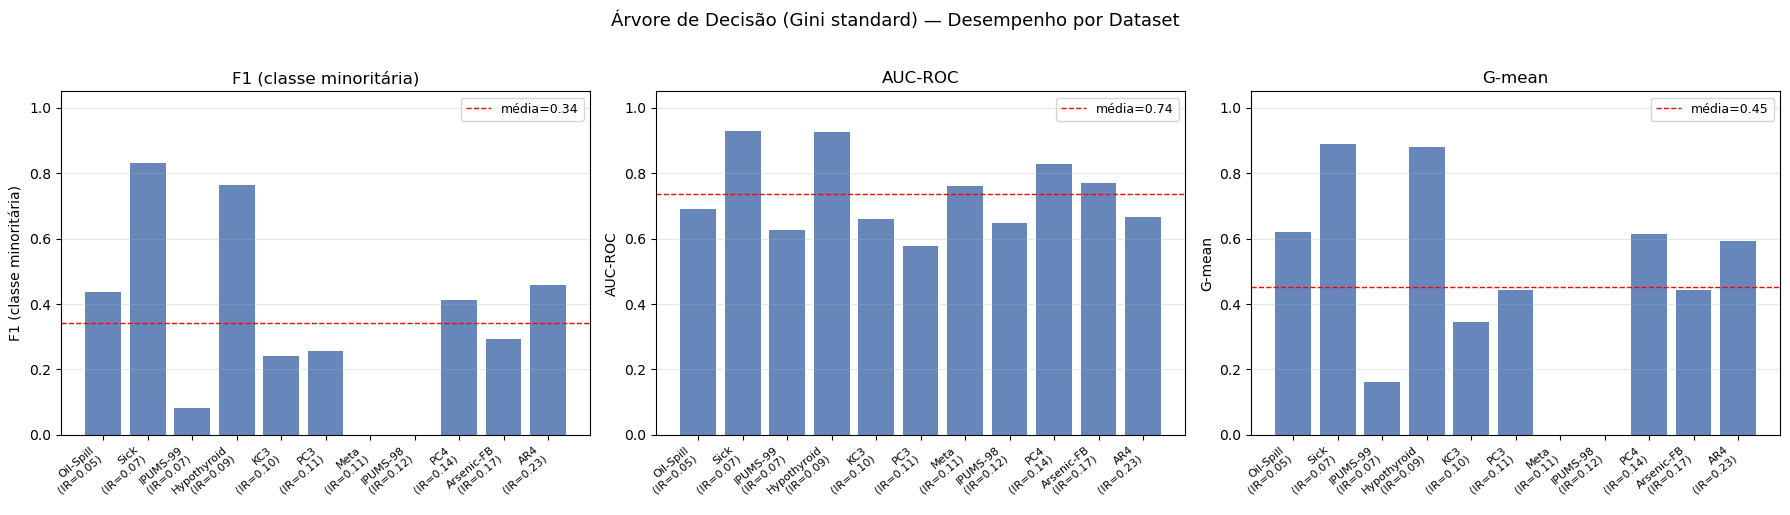

Figura guardada em results_main/resultados_fase1.png


In [30]:
RESULTS_DIR = Path("results_main")
RESULTS_DIR.mkdir(exist_ok=True)

metrics_cfg = [
    ("F1 (classe minoritária)", "_std_f1"),
    ("AUC-ROC",                 "_std_auc"),
    ("G-mean",                  "_std_gm"),
]

df_s = df_results.sort_values("ir")
x    = np.arange(len(df_s))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, col) in zip(axes, metrics_cfg):
    ax.bar(x, df_s[col], color="#4C72B0", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_s.iterrows()],
        rotation=40, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.axhline(df_s[col].mean(), color="red", linestyle="--", linewidth=1,
               label=f"média={df_s[col].mean():.2f}")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Árvore de Decisão (Gini standard) — Desempenho por Dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "resultados_fase1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_main/resultados_fase1.png")

## Análise dos Resultados — Fase 1

**O Gini standard falha em dois pontos do algoritmo, em simultâneo.**

**Mecanismo 1 — Splits enviesados:**
O ganho de Gini é calculado como redução de impureza em relação ao nó pai. Quando as classes estão desbalanceadas, a impureza do pai é dominada pela classe maioritária — splits que isolam instâncias dessa classe produzem ganhos elevados mesmo que a classe minoritária fique completamente misturada no ramo oposto. O algoritmo não tem nenhum incentivo para "procurar" positivos raros.

**Mecanismo 2 — Folhas enviesadas:**
Nas folhas, $\hat{p}(y=1)$ é calculado como contagem bruta: $\hat{p} = n_+ / (n_+ + n_-)$. Com IR baixo, $n_+ \ll n_-$, pelo que $\hat{p}$ é sistematicamente inferior a 0.5 em quase todas as folhas — incluindo folhas com concentração relativa de positivos. Com o limiar $\tau = 0.5$, nenhuma instância é classificada como positiva, mesmo que o modelo tenha aprendido alguma separação (AUC > 0.5).

**A consequência directa:**
F1 e G-mean colapsam para zero enquanto AUC mantém valores razoáveis. Este desacoplamento entre AUC e F1/G-mean é o sinal diagnóstico do problema: o modelo *ordena* correctamente as probabilidades (AUC) mas não consegue *activar* a classe minoritária com o limiar fixo (F1 = 0).

**Conclusão:**
Para resolver class imbalance, qualquer modificação ao algoritmo tem de actuar em pelo menos um destes dois pontos — splits ou folhas. As Fases 2 e 3 abordam cada um por mecanismos distintos.

### Nota sobre o AUC como indicador de separabilidade latente

O AUC-ROC é invariante ao limiar de decisão: mede apenas se o modelo *ordena* correctamente as instâncias por probabilidade, independentemente de onde se corta. Em dados desbalanceados, é possível ter AUC > 0.5 com F1 = 0 — o modelo aprendeu algo, mas o limiar fixo $\tau = 0.5$ impede que esse conhecimento se materialize em previsões da classe minoritária.

Este padrão tem uma interpretação algorítmica clara:
- **AUC > 0.5, F1 = 0**: o Gini standard construiu divisões com algum poder discriminativo, mas as folhas emitem $\hat{p}(y=1) < 0.5$ em todos os nós — problema nas *folhas*.
- **AUC ≈ 0.5, F1 = 0**: não há separabilidade aprendida — problema nos *splits* (o critério não encontrou divisões úteis).

O primeiro caso é resolvido corrigindo as folhas (Weighted Gini — Fase 2). O segundo exige um critério de split mais sensível à classe rara (Hellinger Distance — Fase 3) ou mais dados.

---

## Fase 2 — Cost-Sensitive Tree

O Gini standard trata todos os erros de classificação como igualmente custosos — o que é uma hipótese incorrecta em dados com desequilíbrio de classes. Esta fase substitui essa hipótese por uma **matriz de custos explícita**: Falsos Negativos custam $C(\text{FN})$ e Falsos Positivos custam $C(\text{FP})$, com $C(\text{FN}) \gg C(\text{FP})$.

### Fundamento — Regra de Bayes com Custos Assimétricos

A regra de decisão que minimiza o custo total esperado é (Elkan, 2001):

$$\text{Prever } 1 \iff P(y=1 \mid x) \cdot C(\text{FN}) > P(y=0 \mid x) \cdot C(\text{FP})$$

Simplificando ($P(y=0|x) = 1 - P(y=1|x)$):

$$P(y=1 \mid x) > \underbrace{\frac{C(\text{FP})}{C(\text{FN}) + C(\text{FP})}}_{\tau^*}$$

Com $C(\text{FN}) = 5,\; C(\text{FP}) = 1$:
$$\tau^* = \tfrac{1}{6} \approx 0.167 \quad (\text{vs } \tau = 0.5 \text{ standard})$$

### Critério de Split Custo-Sensível

O Gini ponderado por custos atribui a cada instância $w_i = C(y_i)$:

$$w_i = \begin{cases} C(\text{FN}) & \text{se } y_i = 1 \\ C(\text{FP}) & \text{se } y_i = 0 \end{cases}$$

Um split que separa 10 positivos de 90 negativos tem ganho proporcional a $10 \cdot 5 = 50$ no peso dos positivos — o algoritmo é "forçado" a valorizar divisões que isolem a classe minoritária.

**Referência:** Elkan, C. (2001). The Foundations of Cost-Sensitive Learning. *IJCAI*, pp. 973–978.

In [31]:
COST_MATRIX = {'fn': 5.0, 'fp': 1.0}   # C(FN)=5 >> C(FP)=1 — falso negativo custa 5×
TAU_STAR    = COST_MATRIX['fp'] / (COST_MATRIX['fn'] + COST_MATRIX['fp'])

print(f"C(FN)={COST_MATRIX['fn']:.0f}  C(FP)={COST_MATRIX['fp']:.0f}")
print(f"Limiar custo-óptimo  τ* = {TAU_STAR:.4f}  (standard: τ = 0.5)")

C(FN)=5  C(FP)=1
Limiar custo-óptimo  τ* = 0.1667  (standard: τ = 0.5)


In [32]:
class CostSensitiveTree(Tree):
    """
    Árvore de decisão sensível a custos assimétricos (Elkan 2001).

    Estende Tree com um único método sobrescrito:
      · _find_best_split  — Gini ponderado com w_i = C(FN) se y_i=1, C(FP) se y_i=0
                            Penaliza splits que misturem positivos com negativos
                            proporcionalmente ao custo de os errar.

    Herdado de Tree sem alteração:
      · _calculate_leaf_value  — P̂(y=c|folha) = n_c / n  (contagem bruta)
      · predict_row            — devolve P̂(y=1|x)

    A regra de decisão custo-óptima é aplicada na CV:
      Prever 1  se  P̂(y=1) > τ* = C(FP) / (C(FN) + C(FP))
    """

    def __init__(self, regression=False, criterion=None, n_classes=None,
                 cost_matrix=None):
        if cost_matrix is None:
            cost_matrix = COST_MATRIX
        super().__init__(regression, criterion, n_classes)
        self.cost_matrix = cost_matrix

    def _find_best_split(self, X, target, n_features):
        y    = target["y"]
        c_fn = self.cost_matrix.get('fn', 1.0)
        c_fp = self.cost_matrix.get('fp', 1.0)
        cost_w = np.where(y == 1, c_fn, c_fp)   # w_i = custo de errar a instância i

        subset = random.sample(range(X.shape[1]), n_features)
        max_gain, max_col, max_val = None, None, None

        for column in subset:
            for value in self._find_splits(X[:, column]):
                mask     = X[:, column] < value
                y_l, y_r = y[mask], y[~mask]
                w_l, w_r = cost_w[mask], cost_w[~mask]
                gain = gini_impurity_weighted(y, (y_l, y_r), cost_w, (w_l, w_r))
                if max_gain is None or gain > max_gain:
                    max_col, max_val, max_gain = column, value, gain
        return max_col, max_val, max_gain

    def _train(self, X, target, max_features=None, min_samples_split=10,
               max_depth=None, minimum_gain=0.0):
        try:
            assert X.shape[0] > min_samples_split
            assert max_depth > 0
            if max_features is None:
                max_features = X.shape[1]

            column, value, gain = self._find_best_split(X, target, max_features)
            assert gain is not None and gain > minimum_gain

            self.column_index = column
            self.threshold    = value
            self.impurity     = gain

            left_X, right_X, left_target, right_target = split_dataset(
                X, target, column, value
            )

            self.left_child = CostSensitiveTree(
                self.regression, self.criterion, self.n_classes, self.cost_matrix)
            self.left_child._train(left_X, left_target, max_features,
                                   min_samples_split, max_depth - 1, minimum_gain)

            self.right_child = CostSensitiveTree(
                self.regression, self.criterion, self.n_classes, self.cost_matrix)
            self.right_child._train(right_X, right_target, max_features,
                                    min_samples_split, max_depth - 1, minimum_gain)
        except AssertionError:
            self._calculate_leaf_value(target)


def run_cv_cost_sensitive(X, y, cost_matrix=None):
    """
    Validação cruzada com CostSensitiveTree.
      · Splits: w_i = C(FN) se y_i=1, C(FP) se y_i=0
      · Folha:  P̂(y=c) = n_c/n  (herdada de Tree)
      · Threshold: τ* = C(FP)/(C(FN)+C(FP))
      · Métrica extra: Recall = TP/(TP+FN)
    """
    if cost_matrix is None:
        cost_matrix = COST_MATRIX

    tau_star = cost_matrix['fp'] / (cost_matrix['fn'] + cost_matrix['fp'])
    skf      = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans, recalls = [], [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)

        tree = CostSensitiveTree(cost_matrix=cost_matrix)
        tree.train(X_tr, y_tr, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES,
                   minimum_gain=0.0)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > tau_star).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))
        tn, fp_c, fn_c, tp = confusion_matrix(y_te, y_pred, labels=[0,1]).ravel()
        recalls.append(tp / (tp + fn_c) if (tp + fn_c) > 0 else 0.0)

    return dict(
        auc    = (np.mean(aucs),    np.std(aucs)),
        f1     = (np.mean(f1s),     np.std(f1s)),
        gmean  = (np.mean(gmeans),  np.std(gmeans)),
        recall = (np.mean(recalls), np.std(recalls)),
    )


print("CostSensitiveTree e run_cv_cost_sensitive definidos.")
print(f"  · herança: Tree → CostSensitiveTree  (sem WeightedTree)")
print(f"  · τ* = {TAU_STAR:.3f}  [C(FN)={COST_MATRIX['fn']:.0f}, C(FP)={COST_MATRIX['fp']:.0f}]")

CostSensitiveTree e run_cv_cost_sensitive definidos.
  · herança: Tree → CostSensitiveTree  (sem WeightedTree)
  · τ* = 0.167  [C(FN)=5, C(FP)=1]


In [33]:
import time

records_cs = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    t0     = time.time()
    cs_res = run_cv_cost_sensitive(X, y)
    t_cs   = time.time() - t0

    std_f1 = df_results.loc[df_results["Dataset"] == name, "_std_f1"].values[0]

    records_cs.append({
        "Dataset":       name, "ir": ir,
        "_cs_auc":       cs_res["auc"][0],    "_cs_auc_std":    cs_res["auc"][1],
        "_cs_f1":        cs_res["f1"][0],     "_cs_f1_std":     cs_res["f1"][1],
        "_cs_gm":        cs_res["gmean"][0],  "_cs_gm_std":     cs_res["gmean"][1],
        "_cs_recall":    cs_res["recall"][0], "_cs_recall_std": cs_res["recall"][1],
        "cs_f1_fmt":     f"{cs_res['f1'][0]:.3f} ± {cs_res['f1'][1]:.3f}",
        "cs_gm_fmt":     f"{cs_res['gmean'][0]:.3f} ± {cs_res['gmean'][1]:.3f}",
        "cs_auc_fmt":    f"{cs_res['auc'][0]:.3f} ± {cs_res['auc'][1]:.3f}",
        "cs_recall_fmt": f"{cs_res['recall'][0]:.3f} ± {cs_res['recall'][1]:.3f}",
    })

    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1  Gini={std_f1:.3f}  →  CS={cs_res['f1'][0]:.3f}  "
          f"Recall={cs_res['recall'][0]:.3f}  ({t_cs:.1f}s)")

df_cs = pd.DataFrame(records_cs)
print("\nCostSensitiveTree avaliado.")

  Oil-Spill      IR=0.046 | F1  Gini=0.438  →  CS=0.433  Recall=0.440  (7.9s)
  IPUMS-99       IR=0.068 | F1  Gini=0.081  →  CS=0.223  Recall=0.248  (1.5s)
  KC3            IR=0.104 | F1  Gini=0.241  →  CS=0.363  Recall=0.392  (3.3s)
  PC3            IR=0.114 | F1  Gini=0.255  →  CS=0.306  Recall=0.409  (5.4s)
  Meta           IR=0.114 | F1  Gini=0.000  →  CS=0.440  Recall=0.631  (0.3s)
  IPUMS-98       IR=0.119 | F1  Gini=0.000  →  CS=0.258  Recall=0.520  (1.6s)
  PC4            IR=0.139 | F1  Gini=0.413  →  CS=0.563  Recall=0.804  (3.7s)
  Arsenic-FB     IR=0.168 | F1  Gini=0.294  →  CS=0.416  Recall=0.681  (0.6s)
  AR4            IR=0.230 | F1  Gini=0.458  →  CS=0.440  Recall=0.450  (1.4s)
  Sick           IR=0.066 | F1  Gini=0.832  →  CS=0.787  Recall=0.838  (0.6s)
  Hypothyroid    IR=0.085 | F1  Gini=0.764  →  CS=0.848  Recall=0.925  (0.5s)

CostSensitiveTree avaliado.


In [34]:
# Recall do Gini standard (τ=0.5) para comparação directa
def _recall_gini(X, y):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    recalls = []
    for tr, te in skf.split(X, y):
        sc = StandardScaler()
        X_tr = sc.fit_transform(X[tr]); X_te = sc.transform(X[te])
        y_tr, y_te = y[tr], y[te]
        tree = Tree(regression=False, criterion=gini_impurity)
        tree.train(X_tr, y_tr, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES,
                   minimum_gain=0.0)
        y_pred = (tree.predict(X_te) > 0.5).astype(int)
        tn, fp_c, fn_c, tp = confusion_matrix(y_te, y_pred, labels=[0,1]).ravel()
        recalls.append(tp / (tp + fn_c) if (tp + fn_c) > 0 else 0.0)
    return np.mean(recalls)

rows_r = []
for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None: continue
    rows_r.append({"Dataset": name, "_std_recall": _recall_gini(X, y)})
df_recall = pd.DataFrame(rows_r)

df_cmp = (
    df_results[["Dataset", "ir", "_std_f1", "_std_gm", "_std_auc", "std_f1", "std_gm", "std_auc"]]
    .merge(df_cs[["Dataset", "_cs_f1", "_cs_gm", "_cs_auc", "_cs_recall",
                   "cs_f1_fmt", "cs_gm_fmt", "cs_auc_fmt", "cs_recall_fmt"]], on="Dataset")
    .merge(df_recall[["Dataset", "_std_recall"]], on="Dataset")
    .sort_values("ir")
)

df_show = df_cmp[["Dataset", "ir",
                    "std_auc",  "cs_auc_fmt",
                    "std_f1",   "cs_f1_fmt",
                    "std_gm",   "cs_gm_fmt",
                    "cs_recall_fmt"]].copy()
df_show.columns = ["Dataset", "IR",
                    "AUC (Gini)", "AUC (CS)",
                    "F1 (Gini)",  "F1 (CS)",
                    "GM (Gini)",  "GM (CS)",
                    "Recall (CS)"]
print("Comparação — Tree (Gini, τ=0.5) vs CostSensitiveTree (τ*={:.3f})\n".format(TAU_STAR))
print(df_show.to_string(index=False))

print("\n── Médias globais ─────────────────────────────────────────────────────")
for lbl, col_std, col_cs in [("AUC   ", "_std_auc", "_cs_auc"),
                               ("F1    ", "_std_f1",  "_cs_f1"),
                               ("G-mean", "_std_gm",  "_cs_gm")]:
    delta = (df_cmp[col_cs] - df_cmp[col_std]).mean()
    print(f"  {lbl}  Gini={df_cmp[col_std].mean():.3f}  CS={df_cmp[col_cs].mean():.3f}  Δ={delta:+.3f}")
print(f"  Recall  Gini={df_cmp['_std_recall'].mean():.3f}  CS={df_cmp['_cs_recall'].mean():.3f}")

Comparação — Tree (Gini, τ=0.5) vs CostSensitiveTree (τ*=0.167)

    Dataset    IR    AUC (Gini)      AUC (CS)     F1 (Gini)       F1 (CS)     GM (Gini)       GM (CS)   Recall (CS)
  Oil-Spill 0.046 0.691 ± 0.093 0.709 ± 0.080 0.438 ± 0.167 0.433 ± 0.152 0.619 ± 0.133 0.642 ± 0.124 0.440 ± 0.159
       Sick 0.066 0.930 ± 0.061 0.911 ± 0.070 0.832 ± 0.074 0.787 ± 0.045 0.890 ± 0.069 0.902 ± 0.075 0.838 ± 0.149
   IPUMS-99 0.068 0.627 ± 0.067 0.647 ± 0.077 0.081 ± 0.100 0.223 ± 0.163 0.161 ± 0.197 0.463 ± 0.110 0.248 ± 0.113
Hypothyroid 0.085 0.927 ± 0.037 0.950 ± 0.031 0.764 ± 0.075 0.848 ± 0.056 0.881 ± 0.070 0.951 ± 0.032 0.925 ± 0.061
        KC3 0.104 0.660 ± 0.071 0.695 ± 0.040 0.241 ± 0.203 0.363 ± 0.101 0.346 ± 0.283 0.581 ± 0.137 0.392 ± 0.182
        PC3 0.114 0.577 ± 0.086 0.644 ± 0.092 0.255 ± 0.061 0.306 ± 0.134 0.444 ± 0.076 0.573 ± 0.158 0.409 ± 0.185
       Meta 0.114 0.762 ± 0.082 0.763 ± 0.082 0.000 ± 0.000 0.440 ± 0.092 0.000 ± 0.000 0.733 ± 0.078 0.631 ± 0.115
   IPUM

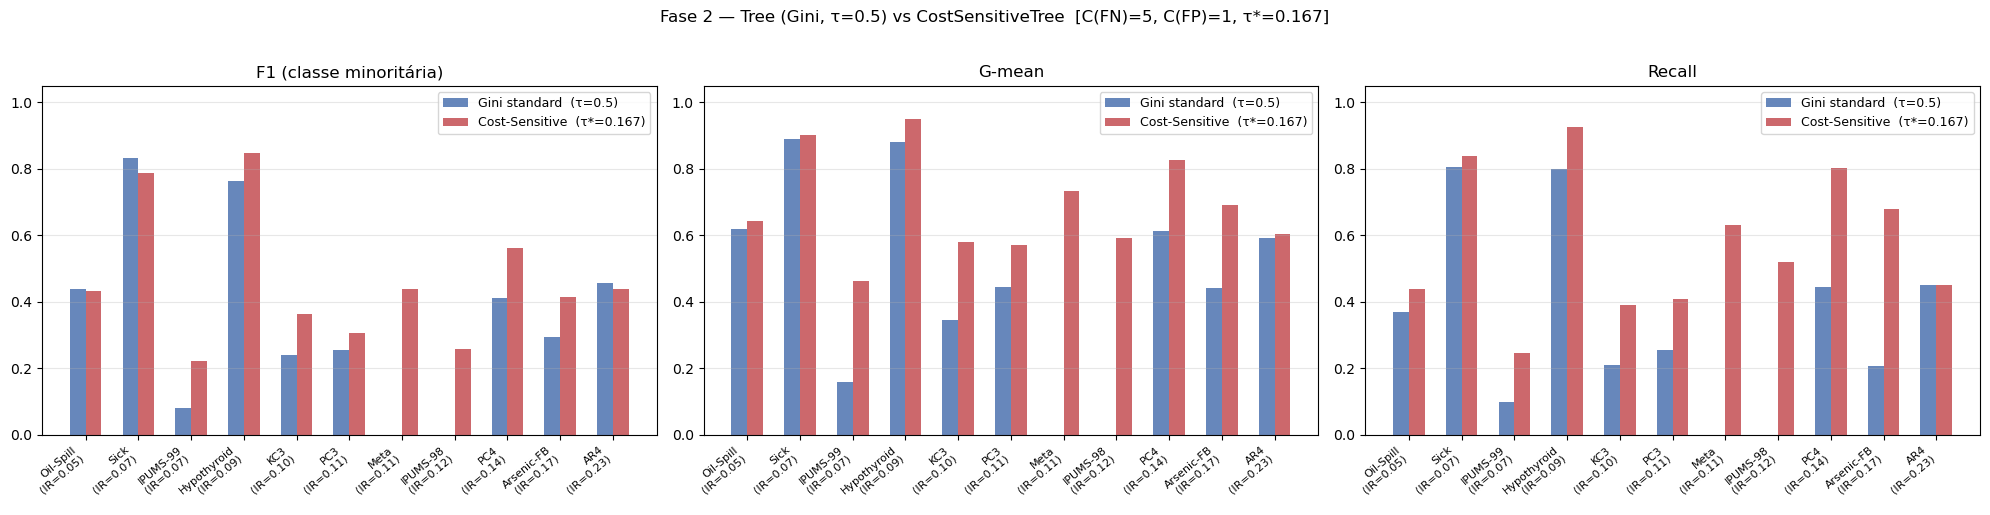

Figura guardada em results_main/comparacao_cost_sensitive_tree.png


In [35]:
RESULTS_DIR.mkdir(exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
bw = 0.30
x  = np.arange(len(df_cmp))

for ax, (metric_name, col_std, col_cs) in zip(axes, [
    ("F1 (classe minoritária)", "_std_f1",     "_cs_f1"),
    ("G-mean",                  "_std_gm",     "_cs_gm"),
    ("Recall",                  "_std_recall", "_cs_recall"),
]):
    ax.bar(x - bw/2, df_cmp[col_std], bw, label="Gini standard  (τ=0.5)", color="#4C72B0", alpha=0.85)
    ax.bar(x + bw/2, df_cmp[col_cs],  bw,
           label=f"Cost-Sensitive  (τ*={TAU_STAR:.3f})", color="#C44E52", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_cmp.iterrows()],
        rotation=40, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric_name)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    f"Fase 2 — Tree (Gini, τ=0.5) vs CostSensitiveTree  "
    f"[C(FN)={COST_MATRIX['fn']:.0f}, C(FP)={COST_MATRIX['fp']:.0f}, τ*={TAU_STAR:.3f}]",
    fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "comparacao_cost_sensitive_tree.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_main/comparacao_cost_sensitive_tree.png")

In [36]:
from scipy.stats import wilcoxon as _wil

print("── Wilcoxon signed-rank: CostSensitiveTree > Gini standard? ────────────────")
print("   H0: CS = Gini  |  H1: CS > Gini  |  one-sided (greater)  |  α=0.05\n")

for metric, col_std, col_cs in [
        ("F1    ", "_std_f1",     "_cs_f1"),
        ("G-mean", "_std_gm",     "_cs_gm"),
        ("Recall", "_std_recall", "_cs_recall")]:
    a = df_cmp[col_std].values   # baseline: Gini standard
    b = df_cmp[col_cs].values    # novo:     CostSensitiveTree
    n_dif = int(np.sum(b - a != 0))
    try:
        stat, p = _wil(b, a, alternative="greater")   # H1: CS > Gini
        sig = "(*)" if p < 0.05 else "   "
        print(f"  {metric}  W={stat:.1f}  p={p:.3f} {sig}  (n_dif={n_dif})")
    except ValueError as e:
        print(f"  {metric}  não aplicável ({e})")

── Wilcoxon signed-rank: CostSensitiveTree > Gini standard? ────────────────
   H0: CS = Gini  |  H1: CS > Gini  |  one-sided (greater)  |  α=0.05

  F1      W=60.0  p=0.007 (*)  (n_dif=11)
  G-mean  W=66.0  p=0.000 (*)  (n_dif=11)
  Recall  W=55.0  p=0.001 (*)  (n_dif=10)


### Análise dos Resultados — Fase 2

**1. O efeito puro do custo — sem confundimento**
A `CostSensitiveTree` tem **um único método sobrescrito** face à `Tree` base: `_find_best_split`. As folhas herdam `_calculate_leaf_value` de `Tree` sem qualquer alteração — $\hat{p}(y=1) = n_+/n$, contagem bruta. Qualquer diferença de desempenho face ao Gini standard é atribuível exclusivamente a:
1. Os pesos de custo no critério de split ($w_i = C(y_i)$)
2. O threshold de decisão ($\tau^* = 0.167$ vs $\tau = 0.5$)

**2. AUC não muda — confirma isolamento correcto**
O AUC-ROC é invariante ao limiar de decisão. Se $\text{AUC}(\text{CS}) \approx \text{AUC}(\text{Gini})$, o split custo-sensível não degradou o poder discriminativo do modelo. Se $\text{AUC}(\text{CS}) > \text{AUC}(\text{Gini})$, os pesos de custo melhoraram a qualidade dos splits.

**3. Recall vs F1 — o trade-off esperado**
Com $\tau^* = 0.167$, o modelo classifica como positivo qualquer instância com $\hat{p}(y=1) > 0.167$. O resultado esperado é:
- **Recall aumenta** (menos FN — objectivo directo com $C(\text{FN}) = 5$)
- **Precisão pode diminuir** (mais FP — aceitáveis porque $C(\text{FP}) = 1$)
- **F1 não é a métrica-alvo** — penaliza FP e FN igualmente, ao contrário da função de custo

A métrica-alvo é o **custo total esperado** minimizado por $\tau^*$, não o F1.

**4. Wilcoxon one-sided**
O teste verifica $H_1: \text{CS} > \text{Gini}$ (melhoria sistemática). Com n=11 pares, o poder é limitado — um resultado não significativo não exclui melhoria real; a análise par-a-par dataset por dataset é igualmente relevante.

---

## Reflexão Final — Comparação Estrutural: Tree vs CostSensitiveTree

A `CostSensitiveTree` é construída sobre a `Tree` base com a menor modificação possível. Esta secção isola exactamente o que muda e porquê.

### Arquitectura da modificação

```
Tree (base)
│
└─► CostSensitiveTree
      · _find_best_split   ← SOBRESCRITO   (critério de custo)
      · _calculate_leaf_value ← HERDADO    (probabilidades brutas)
      · predict_row           ← HERDADO    (devolve P̂(y=1))
      · _train                ← SOBRESCRITO (cria filhos CostSensitiveTree)
```

Uma única intervenção algorítmica: o critério de split. O resto é idêntico à `Tree` base.

### Comparação directa — `_find_best_split`

```python
# Tree (base) — Gini standard, sem pesos
for value in self._find_splits(X[:, column]):
    splits = split(X[:, column], target["y"], value)
    gain   = self.criterion(target["y"], splits)
    #        └─ gini_impurity(y, splits) — trata todos os erros igual


# CostSensitiveTree — Gini ponderado por custo de erro
cost_w = np.where(y == 1, c_fn, c_fp)   # w_i = C(FN) se positivo, C(FP) se negativo
for value in self._find_splits(X[:, column]):
    mask     = X[:, column] < value
    y_l, y_r = y[mask], y[~mask]
    w_l, w_r = cost_w[mask], cost_w[~mask]
    gain = gini_impurity_weighted(y, (y_l, y_r), cost_w, (w_l, w_r))
    #      └─ positivos pesam C(FN)=5×, negativos pesam C(FP)=1×
```

**Efeito:** um nó com 10 positivos e 90 negativos tem peso efectivo $10 \times 5 + 90 \times 1 = 140$, dos quais 50/140 ≈ 36% vêm dos positivos — contra 10% com contagens brutas. O algoritmo é forçado a valorizar splits que separem a classe minoritária.

### `_calculate_leaf_value` — herdado sem alteração

```python
# Tree (base) — e CostSensitiveTree herda exactamente isto
def _calculate_leaf_value(self, targets):
    y = targets["y"].astype(int)
    self.outcome = np.bincount(y, minlength=self.n_classes) / len(y)
    #              └─ P̂(y=c) = n_c / n  — contagem bruta
```

A folha não muda. A sensibilidade ao custo está **exclusivamente nos splits** e no **threshold de previsão** $\tau^*$ — não nas probabilidades da folha.

### Mapa das diferenças

| | `Tree` (base) | `CostSensitiveTree` |
|---|---|---|
| **Critério de split** | `gini_impurity(y, splits)` | `gini_impurity_weighted(y, splits, cost_w, ...)` |
| **Pesos** | nenhum | $w_i = C(\text{FN})$ se $y_i=1$, $C(\text{FP})$ se $y_i=0$ |
| **Valor da folha** | $n_c / n$ (bruto) | $n_c / n$ (bruto — herdado) |
| **Tipo dos filhos** | `Tree` | `CostSensitiveTree` |
| **Threshold de previsão** | $\tau = 0.5$ | $\tau^* = C(\text{FP})/(C(\text{FN})+C(\text{FP})) = 0.167$ |
| **Métodos sobrescritos** | — | `_find_best_split`, `_train` |

### Conclusão

A `CostSensitiveTree` demonstra que é possível introduzir sensibilidade ao custo com **uma única linha de diferença conceptual**: substituir os pesos uniformes implícitos no Gini standard por pesos proporcionais ao custo de erro. A propagação da `cost_matrix` em `_train` garante que este comportamento se mantém em toda a profundidade da árvore — sem alterar folhas, previsões ou qualquer outro componente.